In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from palettable.wesanderson import Darjeeling2_5
from prettytable import PrettyTable
from scipy.stats import chi2_contingency
from statsmodels.sandbox.regression.predstd import wls_prediction_std
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
import pickle
import joblib
warnings.filterwarnings('ignore')

In [2]:
def fa(model, labels , data , part) : 

    keys = [f'Factor_{i}' for i in range(1 , len(labels.keys())+1)]
    columns = [labels[key] for key in keys]

    data_cols = [col for col in data if col not in ['EVENT_ID' , 'PATNO'] and col[-3:] != 'TOT']
    factor_scores = model.transform(data[data_cols].dropna())  # Transform the original data set
    # Create a DataFrame from the scores
    factor_scores_df = pd.DataFrame(factor_scores, columns=columns).add_prefix(f'MDS_UPDRS_P{part}_')
    
    factor_scores_df['PATNO'] = data.dropna(subset=data_cols).reset_index(drop=True)['PATNO']
    factor_scores_df['EVENT_ID'] = data.dropna(subset=data_cols).reset_index(drop=True)['EVENT_ID']
    
    return factor_scores_df


def gen_factors(model = 'PPMI' , data='PPMI' , state='OFF' , model_state_off = False) : 
    if data == 'PPMI' : 
        with open(f'./../../data/02_processed/{data}/P1_MDSUPDRS.pkl' , 'rb') as file : 
            p1 = pickle.load(file)
    
        with open(f'./../../data/02_processed/{data}/P2_MDSUPDRS.pkl' , 'rb') as file : 
            p2 = pickle.load(file)
    else : 
        with open(f'./../../data/02_processed/{data}/P1{state}_MDSUPDRS.pkl' , 'rb') as file : 
            p1 = pickle.load(file)
    
        with open(f'./../../data/02_processed/{data}/P2{state}_MDSUPDRS.pkl' , 'rb') as file : 
            p2 = pickle.load(file)
    
    with open(f'./../../data/02_processed/{data}/P3{state}_MDSUPDRS.pkl' , 'rb') as file : 
        p3 = pickle.load(file)
    
    model_p1 = joblib.load(f"./../../data/03_final/{model}_FA_model_P1.joblib")
    model_p2 = joblib.load(f"./../../data/03_final/{model}_FA_model_P2.joblib")
    if (state == 'ON' or state == 'on') and model_state_off : 
        model_p3 = joblib.load(f"./../../data/03_final/{model}_FA_model_P3OFF.joblib")
    else : 
        model_p3 = joblib.load(f"./../../data/03_final/{model}_FA_model_P3{state}.joblib")

    p1_fa = fa(model_p1['fa'], model_p1['labels'] , p1 , '1')
    p2_fa = fa(model_p2['fa'], model_p2['labels'] , p2 , '2')
    p3_fa = fa(model_p3['fa'], model_p3['labels'] , p3 , '3')

    if data == 'PPMI' : 
        subgroups = pd.read_csv('./../../data/02_processed/PPMI/subgroups.csv', index_col=0)
        
    elif data == 'OPDC' : 
        subgroups = pd.read_csv('./../../data/02_processed/OPDC/subgroups.csv')

    elif data == 'TRACKING' : 
        subgroups = pd.read_csv('./../../data/02_processed/TRACKING/subgroups.csv' , index_col=0)
    
    return pd.merge((pd.merge(p1_fa , p2_fa , on = ['PATNO' , 'EVENT_ID'])), p3_fa , on = ['PATNO' , 'EVENT_ID']) , subgroups

def plot_median_trajectory(
    factor: str,
    df_factors: pd.DataFrame,
    df_demo: pd.DataFrame,
    *,
    group_labels: dict | None = None,
    figsize: tuple[int, int] = (12, 5),
    max_years: int | None = None,
    show_n: bool = True,
    palette: list[str] | None = None,
):
    """
    Plot median trajectory with IQR shading for a single factor, stratified by
    Group, with EVENT_ID binned into yearly intervals.

    Parameters
    ----------
    factor
        Factor column from df_factors, e.g. 'MDS_UPDRS_P1_FATIGUE'.
    df_factors
        Factor score dataframe with columns: PATNO, EVENT_ID, and factor columns.
    df_demo
        Demographic dataframe with columns: PATNO, EVENT_ID, Group, ...
    group_labels
        Optional dict mapping Group values to display names,
        e.g. {1: 'Subtype A', 2: 'Subtype B', 3: 'Subtype C'}.
    figsize
        Figure size.
    max_years
        Optional cap on the maximum year displayed.
    show_n
        Annotate each point with sample size.
    palette
        List of colours, one per group.

    Returns
    -------
    matplotlib.figure.Figure
    """
    # ── Validate ──────────────────────────────────────────────────────────────
    available = [c for c in df_factors.columns if c not in ("PATNO", "EVENT_ID")]
    if factor not in df_factors.columns:
        raise ValueError(
            f"'{factor}' not found in df_factors.\n"
            f"Available factors:\n  " + "\n  ".join(available)
        )

    # ── Merge ────────────────────────────────────────────────────────────────
    df = (
        df_factors[["PATNO", "EVENT_ID", factor]]
        .merge(
            df_demo[["PATNO", "EVENT_ID", "Group"]],
            on=["PATNO", "EVENT_ID"],
            how="inner",
        )
        .dropna(subset=["EVENT_ID", factor, "Group"])
    )

    if df.empty:
        raise ValueError("Merged dataframe is empty — check PATNO/EVENT_ID alignment.")

    # ── Yearly binning ───────────────────────────────────────────────────────
    if max_years is None:
        max_years = int(np.ceil(df["EVENT_ID"].max()))

    bins = np.arange(0, max_years + 1)  # [0, 1, 2, ..., N]

    df["Year_Bin"] = pd.cut(
        df["EVENT_ID"],
        bins=bins,
        labels=bins[:-1],  # label = bin floor
        right=False,       # [0,1), [1,2), ...
    )

    df = df.dropna(subset=["Year_Bin"])
    df["Year_Bin"] = df["Year_Bin"].astype(int)

    # ── Groups & style ───────────────────────────────────────────────────────
    groups = sorted(df["Group"].unique())
    palette = (palette or ["steelblue", "coral", "mediumseagreen"])[: len(groups)]

    if group_labels is None:
        group_labels = {g: f"Group {g}" for g in groups}

    # ── Plot ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    for grp, color in zip(groups, palette):
        stats = (
            df.loc[df["Group"] == grp]
            .groupby("Year_Bin", observed=True)[factor]
            .agg(
                median="median",
                q25=lambda x: x.quantile(0.25),
                q75=lambda x: x.quantile(0.75),
                n="count",
            )
            .reset_index()
            .dropna(subset=["median"])
        )

        x = stats["Year_Bin"].to_numpy()
        med = stats["median"].to_numpy()
        lbl = group_labels.get(grp, f"Group {grp}")

        # Median line
        ax.plot(
            x,
            med,
            color=color,
            lw=2.5,
            marker="o",
            ms=6,
            label=lbl,
            zorder=3,
        )

        # IQR shading
        ax.fill_between(
            x,
            stats["q25"].to_numpy(),
            stats["q75"].to_numpy(),
            color=color,
            alpha=0.15,
            zorder=2,
        )

        # Sample size annotations
        if show_n:
            for _, row in stats.iterrows():
                ax.annotate(
                    f"n={int(row['n'])}",
                    xy=(row["Year_Bin"], row["q75"]),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center",
                    fontsize=7,
                    color=color,
                )

    # ── Axes & style ─────────────────────────────────────────────────────────
    x_vals = sorted(df["Year_Bin"].unique())
    ax.set_xticks(x_vals)
    ax.set_xticklabels(
        [f"Year {y}–{y+1}" for y in x_vals],
        rotation=30,
        ha="right",
    )

    ax.set_xlabel("Time Since Baseline (yearly bins)", fontsize=11)
    ax.set_ylabel("Factor Score", fontsize=11)
    ax.set_title(
        f"Median Trajectory — {factor}",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )

    ax.legend(title="Group", framealpha=0.8, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    ax.text(
        0.99,
        0.01,
        "Shaded region = IQR",
        transform=ax.transAxes,
        fontsize=8,
        ha="right",
        va="bottom",
        color="grey",
    )

    plt.tight_layout()
    return fig

def drop_sparse_time_bins(
    df: pd.DataFrame,
    *,
    min_patient_pct: float = 0.10,
    max_years: int | None = None,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Bin EVENT_ID into yearly intervals and drop bins where the number of unique
    patients falls below a minimum percentage of the total cohort.

    Parameters
    ----------
    df
        DataFrame containing at minimum 'PATNO' and 'EVENT_ID' columns.
    min_patient_pct
        Minimum fraction of total unique patients required to retain a bin.
        Default is 0.10 (10%).
    max_years
        Optional cap on the maximum year bin created. Inferred from data if not
        provided.
    verbose
        If True, print a summary table of kept/dropped bins.

    Returns
    -------
    pd.DataFrame
        A filtered copy of `df` with sparse time bins removed and a 'Year_Bin'
        column added.
    """
    # ── Validate ──────────────────────────────────────────────────────────────
    required = ("PATNO", "EVENT_ID")
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required column(s): {missing}")

    df = df.copy().dropna(subset=["PATNO", "EVENT_ID"])

    # ── Bin into yearly intervals ─────────────────────────────────────────────
    if max_years is None:
        max_years = int(np.ceil(df["EVENT_ID"].max()))

    bins = np.arange(0, max_years + 1)  # 0,1,2,...,max_years

    df["Year_Bin"] = pd.cut(
        df["EVENT_ID"],
        bins=bins,
        labels=bins[:-1],  # floor year label: [0,1)→0, [1,2)→1, ...
        right=False,
    )

    df = df.dropna(subset=["Year_Bin"])
    df["Year_Bin"] = df["Year_Bin"].astype(int)

    # ── Compute unique patient counts per bin ────────────────────────────────
    total_patients = df["PATNO"].nunique()
    min_patients = int(np.ceil(total_patients * min_patient_pct))

    patients_per_bin = (
        df.groupby("Year_Bin", observed=True)["PATNO"]
        .nunique()
        .rename("n_patients")
    )

    valid_bins = patients_per_bin[patients_per_bin >= min_patients].index
    dropped_bins = patients_per_bin[patients_per_bin < min_patients]

    # ── Report ────────────────────────────────────────────────────────────────
    if verbose:
        print(f"Total unique patients : {total_patients}")
        print(f"Minimum required (≥{min_patient_pct:.0%}) : {min_patients}\n")

        print(f"{'Year Bin':<12} {'N Patients':>12} {'% Cohort':>10} {'Status':>10}")
        print("─" * 52)

        for yr, n in patients_per_bin.items():
            pct = 100 * n / total_patients if total_patients else np.nan
            status = "kept" if yr in valid_bins else "dropped"
            print(f"Year {yr}–{yr+1:<4}  {n:>12}  {pct:>9.1f}%  {status:>10}")

        if dropped_bins.empty:
            print("\nNo bins dropped.")

    # ── Filter ────────────────────────────────────────────────────────────────
    filtered = df[df["Year_Bin"].isin(valid_bins)].copy()

    if filtered.empty:
        raise ValueError("All bins dropped — lower min_patient_pct or inspect EVENT_ID range.")

    return filtered



In [3]:
df, subgroups = gen_factors(state='OFF' , data='PPMI' , model='PPMI' , model_state_off=False)
df.drop(columns=['MDS_UPDRS_P3_NA'] , inplace=True)
df['combo'] = df['MDS_UPDRS_P3_PIG'] + df['MDS_UPDRS_P1_COGNITION'] 

In [4]:
df = pd.merge(df , subgroups , on =['PATNO' , 'EVENT_ID'])
df["visit_interval_years"] = (df.groupby("PATNO")["AGE_AT_VISIT"].diff())

# Cumulative years since the subject's first visit: treat the first
# visit's undefined interval as 0, then cumulatively sum the intervals.
df["time_since_first_visit"] = (
    df.groupby("PATNO")["visit_interval_years"].transform(lambda x: x.fillna(0).cumsum())
)

df = df.drop(columns=['EVENT_ID']).rename(columns = {'time_since_first_visit' : 'EVENT_ID'})

subgroups = df[subgroups.columns]

In [5]:
df.columns

Index(['MDS_UPDRS_P1_FATIGUE', 'MDS_UPDRS_P1_DEPRESSION+ANXIETY',
       'MDS_UPDRS_P1_COGNITION', 'PATNO', 'MDS_UPDRS_P2_RISE+WALK',
       'MDS_UPDRS_P2_EAT', 'MDS_UPDRS_P2_SPEECH', 'MDS_UPDRS_P3_TAPPING_L',
       'MDS_UPDRS_P3_TAPPING_R', 'MDS_UPDRS_P3_PIG', 'MDS_UPDRS_P3_RISING',
       'MDS_UPDRS_P3_TREMOR', 'combo', 'Group', 'AGE_AT_VISIT', 'GENDER',
       'visit_interval_years', 'EVENT_ID'],
      dtype='object')

In [6]:
#df = drop_sparse_time_bins(df)

Text(0.5, 1.0, 'PIGD - Median Trajectory per Subtype in PPMI')

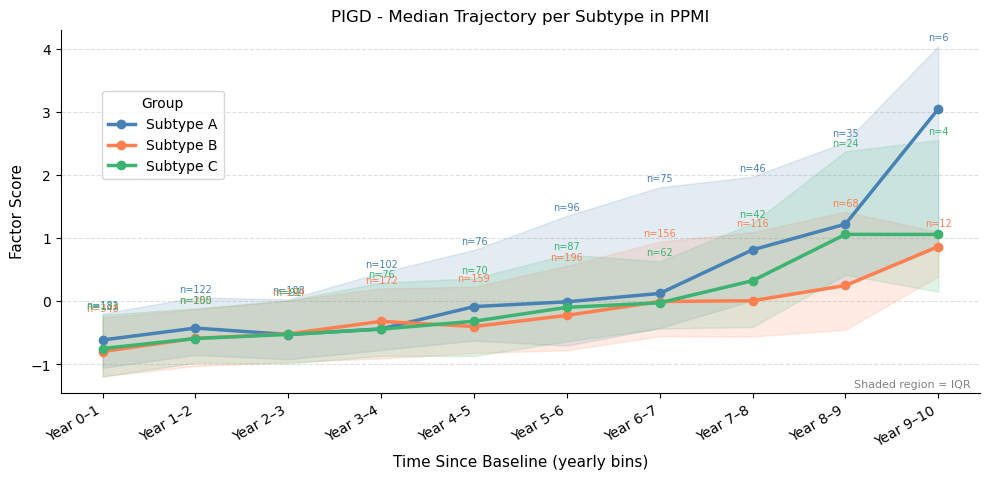

In [7]:
fig = plot_median_trajectory('combo', df , subgroups, figsize=(10,5))
# remove any legends on all axes
for ax in fig.axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# build one figure legend using handles from (one) axis
ax0 = fig.axes[0]
handles, _ = ax0.get_legend_handles_labels()

fig.legend(handles, ["Subtype A", "Subtype B", "Subtype C"], title="Group",
           loc="upper left", bbox_to_anchor=(0.1, 0.8))

ax0.set_title("PIGD - Median Trajectory per Subtype in PPMI")
#fig.savefig('./../Results/ppmi_PIG_trajectory.svg')